In [1]:
your_folder = "D:/Python_TK_3/datas/regist_images"  # don't change
date = "251119_GCaMP"  ## date of experiments
analysis_folder = "251119_01"  ## number of experiment

In [2]:
import glob
import numpy as np
from tifffile import imread

frames = 1600

# フォルダ内の.tifファイル一覧を取得（パスは適宜変更）
filelist1 = sorted(glob.glob("L:/s7f_cortex/251119/01/*.tif"))
#filelist2 = sorted(glob.glob("F:/2023TK/s7f_cortex/250310/01/01_2/*.tif"))

# ファイルが見つからない場合のチェック
if not filelist1:
    raise FileNotFoundError("指定したフォルダに .tif ファイルが見つかりません。")
#if not filelist2:
    #raise FileNotFoundError("指定したフォルダに .tif ファイルが見つかりません。")

# 各.tifファイルを読み込み、リストに格納
images1 = [imread(file) for file in filelist1]
#images2 = [imread(file) for file in filelist2]

# 画像をNumPy配列として連結（形状: (枚数, 高さ, 幅)）
all_tif1 = np.stack(images1, axis=0)
#all_tif2 = np.stack(images2, axis=0)

# 結果を確認
print("Combined array1 shape:", all_tif1.shape)  # (枚数, 高さ, 幅)
#print("Combined array2 shape:", all_tif2.shape)  # (枚数, 高さ, 幅)

Combined array1 shape: (17600, 256, 270)


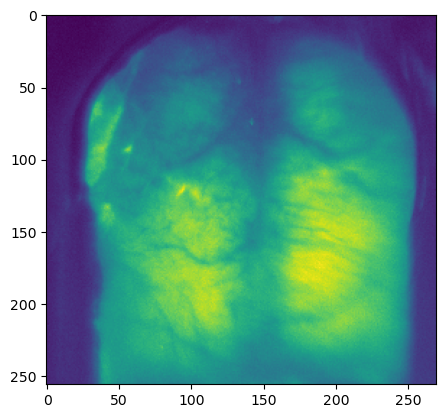

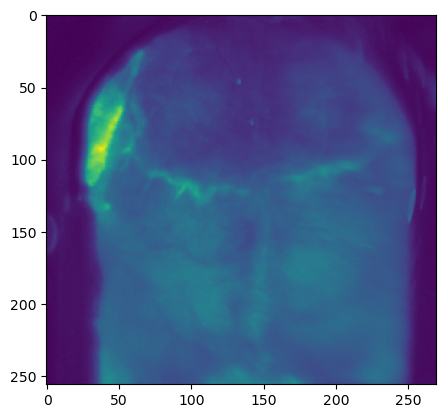

In [3]:
import matplotlib.pyplot as plt

plt.imshow(all_tif1[1600])
plt.show()

plt.imshow(all_tif1[1601])
plt.show()

In [4]:
all_tif1 = all_tif1[1600:]
print(all_tif1.shape)

(16000, 256, 270)


In [5]:
#all_tif1 = all_tif1[:1600*4]
#print(all_tif1.shape)

In [6]:
#all_tif1 = np.concatenate((all_tif1[1600:11200], all_tif1[12800:]), axis=0)
#print(all_tif1.shape)

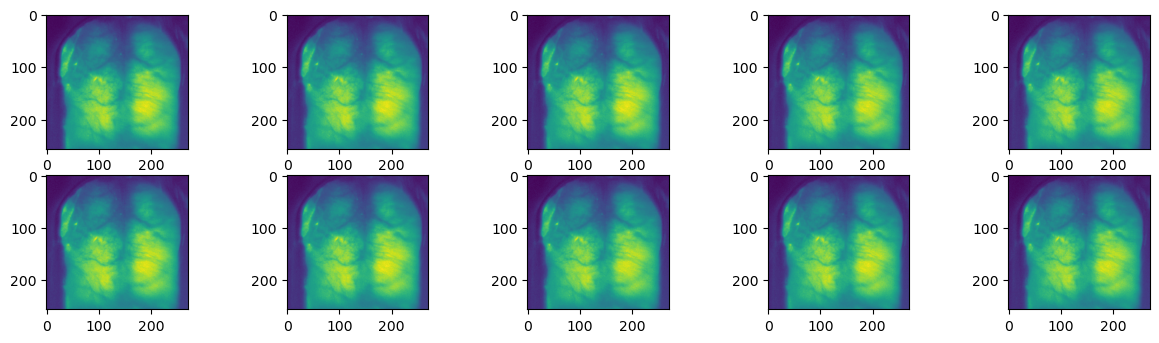

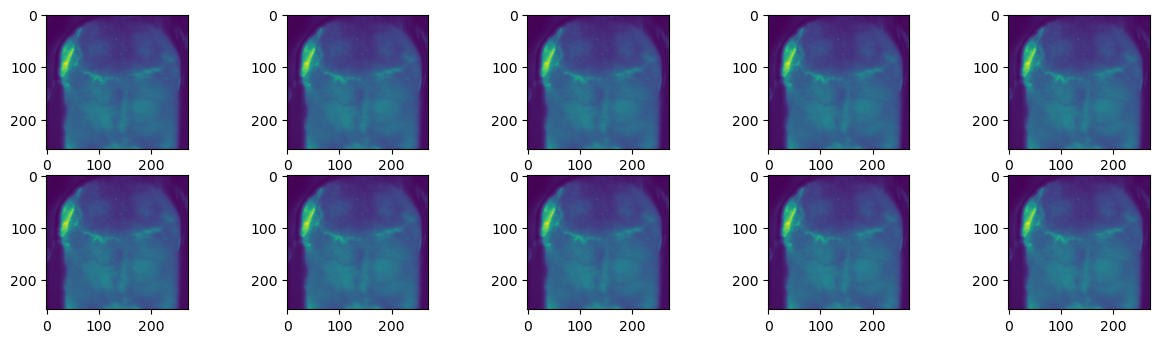

In [7]:
import matplotlib.pyplot as plt

ex_nums = 10

plt.figure(figsize=(15, 8))  # 幅12インチ、高さ8インチのFigureを作成
for ex in range(ex_nums):  # Start from 1 and end at 15 (inclusive)
  plt.subplot(4, 5, ex+1)
  plt.imshow(all_tif1[ex*frames])
  # ... rest of your code
plt.show()

plt.figure(figsize=(15, 8))  # 幅12インチ、高さ8インチのFigureを作成
for ex in range(ex_nums):  # Start from 1 and end at 15 (inclusive)
  plt.subplot(4, 5, ex+1)
  plt.imshow(all_tif1[(ex+1)*frames-1])
  # ... rest of your code
plt.show()

In [8]:
import os
from wfield import *

os.mkdir(f"{your_folder}/{date}")
os.mkdir(f"{your_folder}/{date}/{analysis_folder}")

base_path = f"{your_folder}/{date}/{analysis_folder}"
path = pjoin(base_path, "dat")
os.mkdir(path)

In [9]:
import tifffile as tiff

frames = 1600

ex_in1 = int(all_tif1.shape[0] / frames)
for ex in range(ex_in1): 
    subfolder = pjoin(path, f"ex{ex}")
    os.mkdir(subfolder)
    file_path = os.path.join(subfolder, f"ex{ex}.tif")
    tiff.imwrite(file_path, all_tif1[ex*frames:(ex+1)*frames])

In [10]:
import tifffile as tiff

image_path = os.path.join(path, f"{analysis_folder}_1f.tif")
tiff.imwrite(image_path, all_tif1[0])

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def roi_setting(img_array):

    # 仮の3次元データ (時間, y, x) を作成
    time_steps, height, width = img_array.shape

    # 複数のROIを定義（各ROIは (y, x) 形状のバイナリマスク）
    roi1 = np.zeros((height, width), dtype=bool)
    roi1[200:230, 180:210] = 1  # 例として (10:20, 10:20) 領域をROI1に設定

    rois = [roi1]

    # 各ROIの平均値の経時変化を計算
    roi_means = []
    for roi in rois:
        # 各時間ステップでROI領域の平均を計算
        mean_values = np.array([np.mean(frame[roi]) for frame in img_array])
        roi_means.append(mean_values)

    # 結果を numpy 配列に変換
    roi_means = np.array(roi_means)

    print("各ROIの経時変化平均値:", roi_means.shape)  # (ROIの数, 時間)

    # 1フレーム目のデータに各ROIを重ねて表示
    plt.figure(figsize=(6, 6))
    plt.imshow(img_array[0], cmap='gray', interpolation='nearest')  # 1フレーム目を表示

    # 各ROIを異なる色で表示
    for idx, roi in enumerate(rois):
        #plt.contour(roi, colors=[f'C{idx}'], linewidths=1.5, label=f'ROI {idx + 1}')
        plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')

    plt.show()

    return roi_means

In [12]:
import numpy as np
import matplotlib.pyplot as plt

frames = 800

def roi_calc(img_array):

    # 仮の3次元データ (時間, y, x) を作成
    time_steps, height, width = img_array.shape
    # 複数のROIを定義（各ROIは (y, x) 形状のバイナリマスク）
    roi = np.zeros((height, width), dtype=bool)
    roi[200:230, 180:210] = 1  # 例として (10:20, 10:20) 領域をROI1に設定
    mean_values = np.array([np.mean(frame[roi]) for frame in img_array])
    
    return mean_values

In [13]:
# 初期値
start_value = 0.0

# 増加量
increment = 0.05

# 繰り返し回数
count = 800

# リストを生成
t = [start_value + i * increment for i in range(count)]

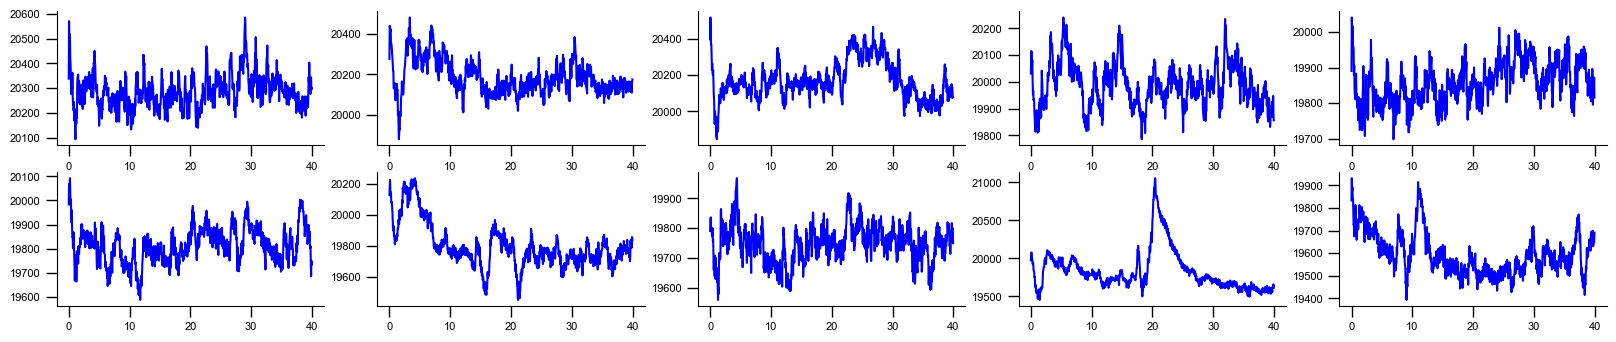

In [14]:
plt.figure(figsize=(20, 8))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(all_tif1.shape[0]/(frames*2))):
    mean_values = roi_calc(all_tif1[ex*frames*2:(ex+1)*frames*2][::2])
    plt.subplot(4, 5, ex+1)
    plt.plot(t[:frames], mean_values, color='blue')
    #for set in range(16):
     #       plt.axvspan(set+0.5, set+1, color='black', alpha=0.3)
    #for set in range(16, 40):
     #   plt.axvspan(set+0.5, set+1, color='blue', alpha=0.3)
    #for dev in range(3):
     #   plt.axvspan(dev*8+21.5, dev*8+22, color='red', alpha=0.3)      


plt.show()

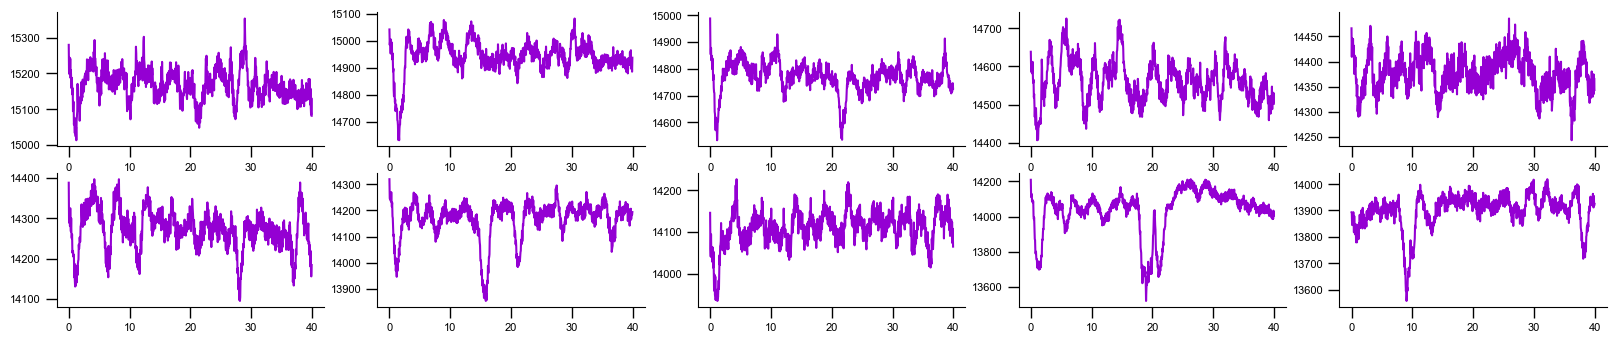

In [15]:
plt.figure(figsize=(20, 8))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(all_tif1.shape[0]/(frames*2))):
    mean_values = roi_calc(all_tif1[ex*frames*2:(ex+1)*frames*2][1::2])
    plt.subplot(4, 5, ex+1)
    plt.plot(t[:frames], mean_values, color='darkviolet')
    #for set in range(16):
     #       plt.axvspan(set+0.5, set+1, color='black', alpha=0.3)
    #for set in range(16, 40):
     #   plt.axvspan(set+0.5, set+1, color='blue', alpha=0.3)
    #for dev in range(3):
     #   plt.axvspan(dev*8+21.5, dev*8+22, color='red', alpha=0.3)     
    
plt.show()

各ROIの経時変化平均値: (1, 800)


C:\Users\user\AppData\Local\Temp\ipykernel_15808\3975532313.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')


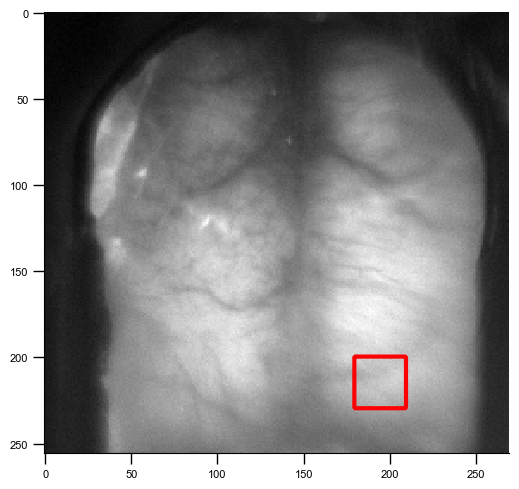

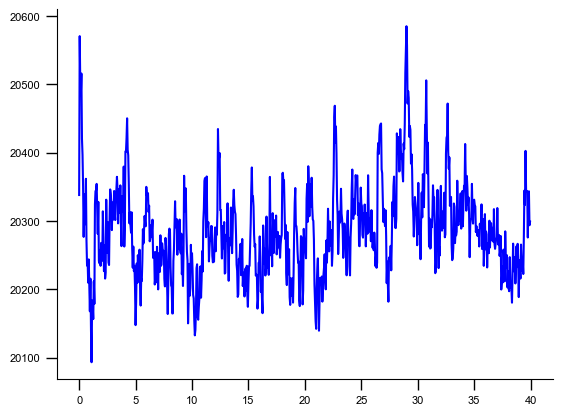

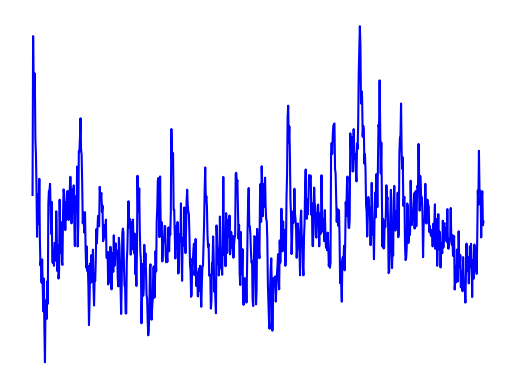

In [16]:
frames = 800

roi_means = roi_setting(all_tif1[:2*frames][::2])
for i in range(roi_means.shape[0]):
    plt.plot(t[:frames], roi_means[i][:frames], color='blue')
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(t[:frames], roi_means[i][:frames], color='blue')
    # 上、下、左、右の枠線を個別に非表示にする
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

各ROIの経時変化平均値: (1, 800)


C:\Users\user\AppData\Local\Temp\ipykernel_15808\3975532313.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')


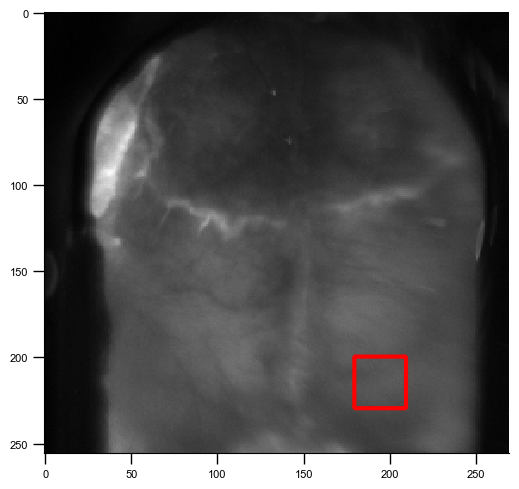

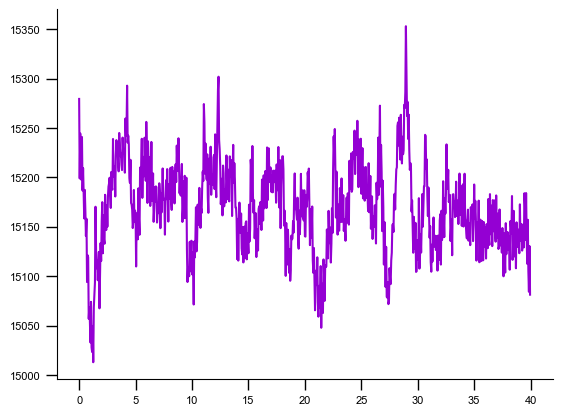

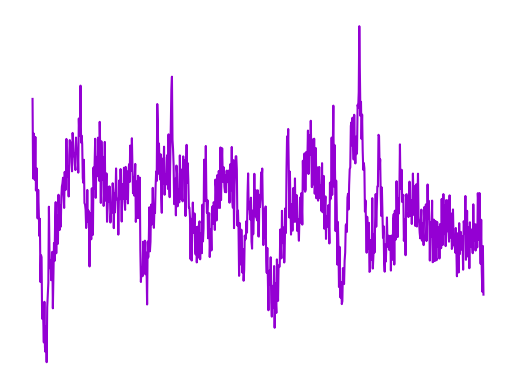

In [17]:
roi_means = roi_setting(all_tif1[:2*frames][1::2])
for i in range(roi_means.shape[0]):
    plt.plot(t[:frames], roi_means[i][:frames], color='darkviolet')
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(t[:frames], roi_means[i][:frames], color='darkviolet')
    # 上、下、左、右の枠線を個別に非表示にする
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

In [18]:
#tiff.imwrite(os.path.join(path, "250428_01_ex1_470nm.tif"), all_tif1[1600:3200][::2])
#tiff.imwrite(os.path.join(path, "250428_01_ex1_405nm.tif"), all_tif1[1600:3200][1::2])